In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
#Filling missing Age with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [5]:
#Filling missing Embarked with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

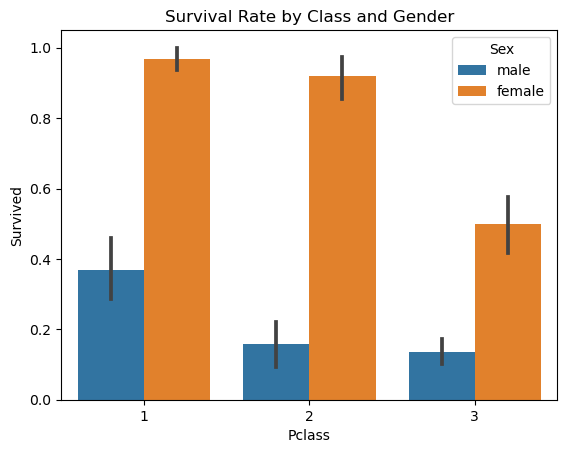

In [6]:
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Class and Gender')
plt.show()

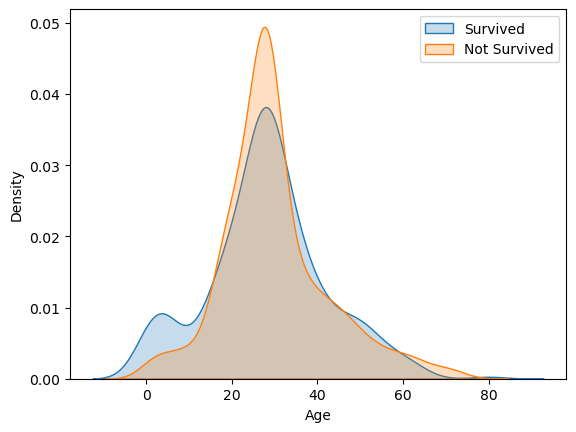

In [7]:
sns.kdeplot(data=df[df['Survived'] == 1], x='Age', label='Survived', fill=True)
sns.kdeplot(data=df[df['Survived'] == 0], x='Age', label='Not Survived', fill=True)
plt.legend()
plt.show()

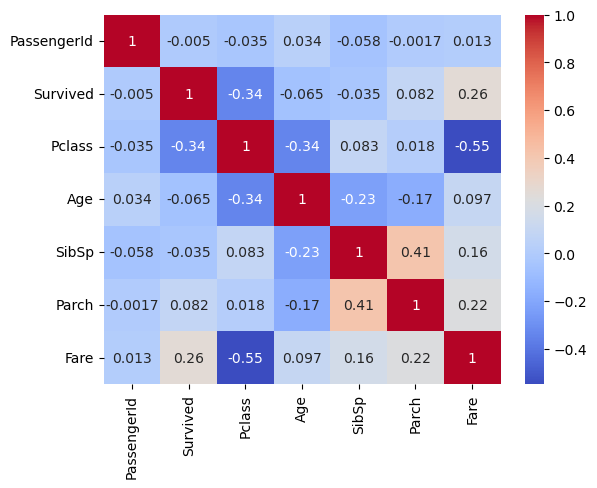

In [8]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

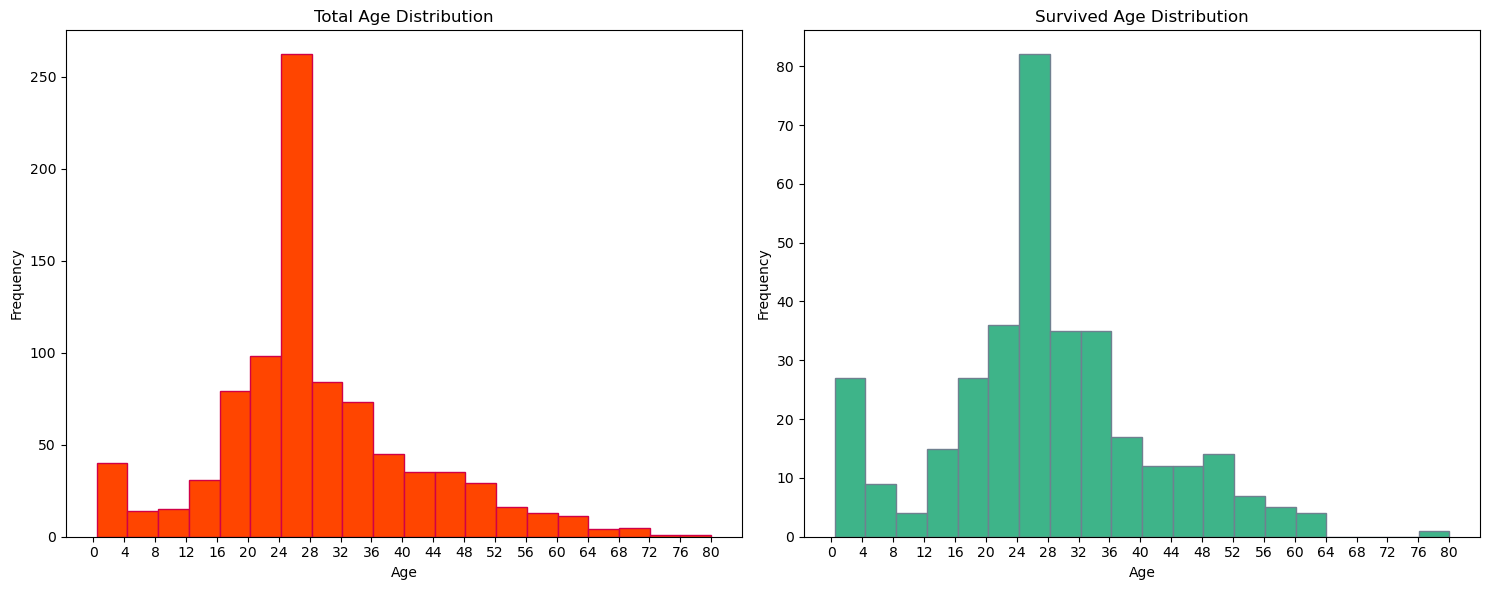

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(df.Age.dropna(), bins=20, color='#FF4500', edgecolor='#d10047')
ax1.set_xticks(np.arange(0, 84, 4))
ax1.set_title("Total Age Distribution")
ax1.set_xlabel("Age")
ax1.set_ylabel("Frequency")

var5 = df[df.Survived == 1].Age.dropna()
ax2.hist(var5, bins=20, color='#3eb489', edgecolor='#708090', label="Age bins")
ax2.set_xticks(np.arange(0, 84, 4))
ax2.set_title("Survived Age Distribution")
ax2.set_xlabel("Age")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

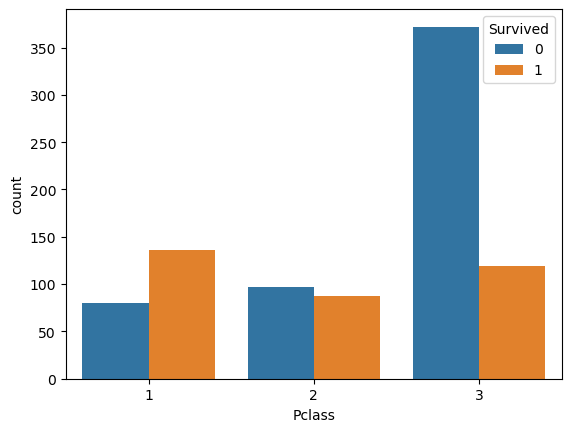

In [10]:
sns.countplot(x = "Pclass",hue = "Survived", data = df)

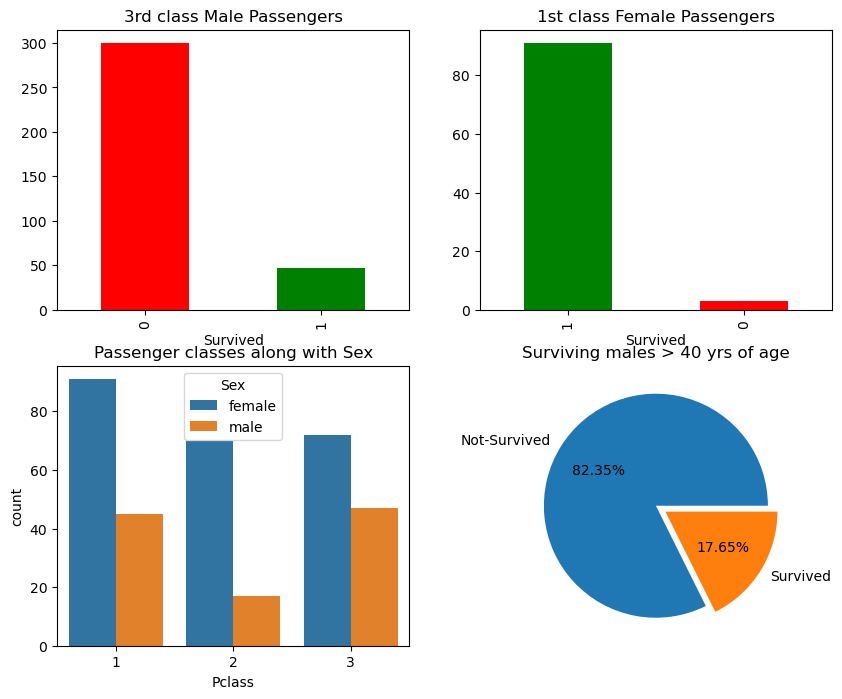

In [11]:
fig,axs = plt.subplots(2,2, figsize = (10,8))
var1= df[(df.Pclass==3) & (df.Sex =='male')].Survived.value_counts()
var1.plot(kind = 'bar',color=['r','g'],ax = axs[0][0])
axs[0][0].set_title("3rd class Male Passengers")

var2= df[(df.Pclass==1) & (df.Sex =='female')].Survived.value_counts()
var2.plot(kind = 'bar',color=['g','r'],ax = axs[0][1])
axs[0][1].set_title("1st class Female Passengers")

sns.countplot(x = "Pclass",hue = "Sex", data = df[df.Survived == 1], ax = axs[1,0])
axs[1][0].set_title("Passenger classes along with Sex")

var4 = df.loc[(df.Age > 40) & (df.Sex == 'male'), 'Survived'].value_counts()
axs[1][1].pie(var4, autopct='%0.2f%%', labels=["Not-Survived","Survived"],
        explode=(0,0.1))
axs[1][1].set_title("Surviving males > 40 yrs of age")

plt.show()

In [12]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [13]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [14]:
#(One-Hot Encoding)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [15]:
print("Preprocessed Data Head:")
print(df.head())

Preprocessed Data Head:
   Survived  Pclass   Age  SibSp  Parch     Fare  FamilySize  Sex_male  \
0         0       3  22.0      1      0   7.2500           2      True   
1         1       1  38.0      1      0  71.2833           2     False   
2         1       3  26.0      0      0   7.9250           1     False   
3         1       1  35.0      1      0  53.1000           2     False   
4         0       3  35.0      0      0   8.0500           1      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [16]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
predictions = model.predict(X_test)

In [20]:
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")

Model Accuracy: 82.68%


In [21]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



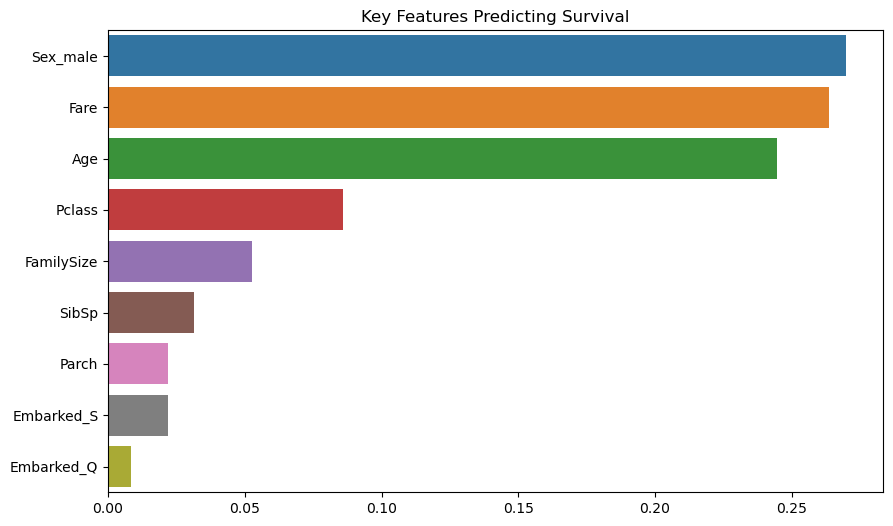

In [22]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Key Features Predicting Survival")
plt.show()